In [39]:
import torch
import torchvision
from torchvision import models, transforms
from torchvision.models import (
    ResNet18_Weights,
    MobileNet_V3_Small_Weights,
    EfficientNet_B0_Weights,
)
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import time
import random
import copy
import os
from pathlib import Path
from sklearn.decomposition import PCA

os.makedirs("outputs", exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

DATA_DIR = Path("/kaggle/input/intel-image-classification/seg_test/seg_test")
LABELS = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

random.seed(42)

Using device: cpu


## Task 1: Environment Setup and Data Loading

In [40]:
from pathlib import Path
from PIL import Image
import random

DATA_DIR = Path("/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test")

def load_images(n_per_class=10):
    image_set = []

    for label in LABELS:
        class_dir = DATA_DIR / label
        paths = list(class_dir.glob("*.jpg"))

        print(label, "images found:", len(paths))

        if len(paths) == 0:
            continue

        selected_paths = random.sample(paths, min(n_per_class, len(paths)))

        for path in selected_paths:
            img = Image.open(path).convert("RGB")
            image_set.append((img, label))

    random.shuffle(image_set)
    return image_set


image_set = load_images(n_per_class=10)

print(f"Total images loaded: {len(image_set)}")

buildings images found: 437
forest images found: 474
glacier images found: 553
mountain images found: 525
sea images found: 510
street images found: 501
Total images loaded: 60


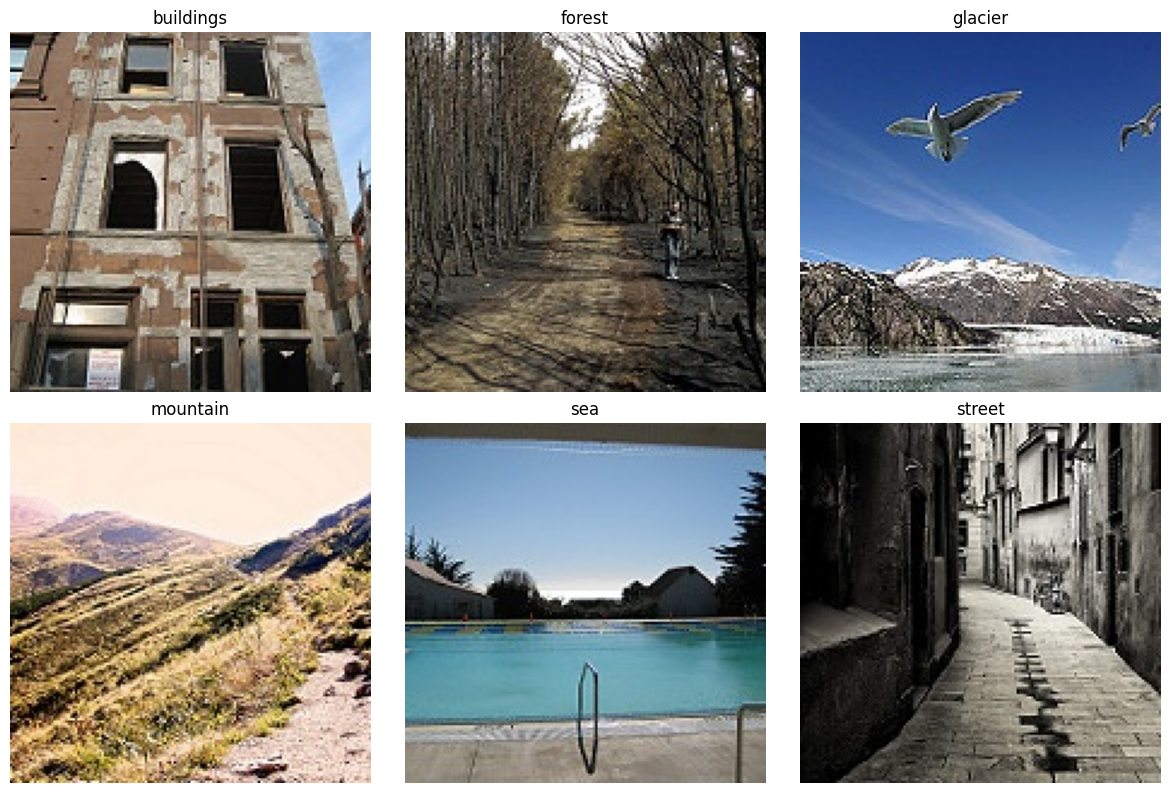

Saved dataset sample to outputs/dataset_sample.png


In [41]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i, label in enumerate(LABELS):
    sample_img = None

    for img, true_label in image_set:
        if true_label == label:
            sample_img = img
            break

    if sample_img is not None:
        axes[i].imshow(sample_img)
        axes[i].set_title(label)
    else:
        axes[i].text(0.5, 0.5, f"No image found\n{label}", ha="center", va="center")
        axes[i].set_title(label)

    axes[i].axis("off")

plt.tight_layout()
plt.savefig("outputs/dataset_sample.png")
plt.show()

print("Saved dataset sample to outputs/dataset_sample.png")

A pretrained ImageNet model is a reasonable starting point for this data. The labels are not an exact match, but ImageNet models have already learned useful visual features like edges, textures, shapes, trees, water, roads, and mountains. Even if the model outputs labels like "alp" or "lakeside" instead of "mountain" or "sea", those predictions can still be useful for understanding outdoor scene images.

## Task 2: Baseline Inference with ResNet18

In [42]:
resnet_weights = ResNet18_Weights.DEFAULT
resnet = models.resnet18(weights=resnet_weights).to(device).eval()
resnet_preproc = resnet_weights.transforms()
imagenet_classes = resnet_weights.meta["categories"]

print(f"ResNet18 parameters: {sum(p.numel() for p in resnet.parameters()):,}")

ResNet18 parameters: 11,689,512


In [43]:
def run_inference(model, preprocess, image, device, class_labels, top_k=5):
    tensor = preprocess(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(tensor)

    probabilities = torch.nn.functional.softmax(output[0], dim=0)
    top_probs, top_indices = torch.topk(probabilities, top_k)

    results = []

    for prob, index in zip(top_probs, top_indices):
        class_name = class_labels[index.item()]
        results.append((class_name, prob.item()))

    return results

In [44]:
resnet_results = []

for img, true_label in image_set:
    preds = run_inference(resnet, resnet_preproc, img, device, imagenet_classes)

    resnet_results.append({
        "true_label": true_label,
        "top1_class": preds[0][0],
        "top1_prob": preds[0][1],
        "top5_classes": [p[0] for p in preds],
        "top5_probs": [p[1] for p in preds],
    })

print(f"Processed {len(resnet_results)} images.")

Processed 60 images.


In [45]:
overall_mean = np.mean([r["top1_prob"] for r in resnet_results])

print(f"Overall mean top-1 probability: {overall_mean:.4f}")

print("\nMean top-1 probability by class:")

class_means = {}

for label in LABELS:
    probs = [r["top1_prob"] for r in resnet_results if r["true_label"] == label]
    class_means[label] = np.mean(probs)
    print(f"{label:10s}: {class_means[label]:.4f}")

Overall mean top-1 probability: 0.4195

Mean top-1 probability by class:
buildings : 0.2889
forest    : 0.2477
glacier   : 0.4993
mountain  : 0.5556
sea       : 0.5710
street    : 0.3544


/tmp/ipykernel_57/434269967.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=LABELS)


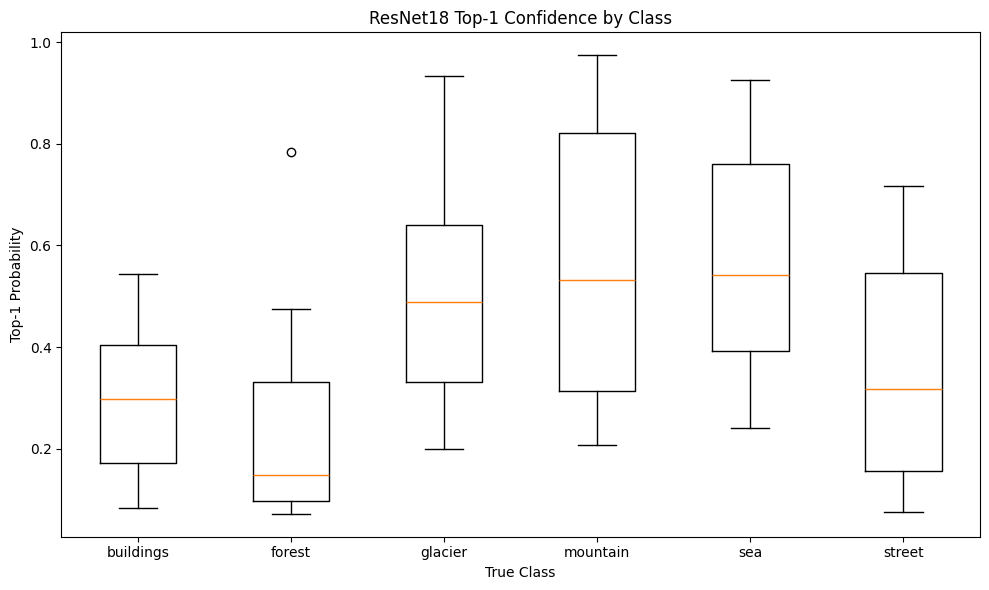

Saved boxplot to outputs/resnet18_confidence_by_class.png


In [46]:
boxplot_data = []

for label in LABELS:
    probs = [r["top1_prob"] for r in resnet_results if r["true_label"] == label]
    boxplot_data.append(probs)

plt.figure(figsize=(10, 6))
plt.boxplot(boxplot_data, labels=LABELS)
plt.title("ResNet18 Top-1 Confidence by Class")
plt.xlabel("True Class")
plt.ylabel("Top-1 Probability")
plt.tight_layout()
plt.savefig("outputs/resnet18_confidence_by_class.png")
plt.show()

print("Saved boxplot to outputs/resnet18_confidence_by_class.png")

High confidence and high accuracy are not the same thing. A model can be confident and still predict the wrong label. In a production image tagging pipeline, I would use confidence scores to decide which predictions are safe to auto-tag and which should be reviewed by a human. I would flag predictions below around 0.70 confidence for human review.

## Task 3: Multi-Model Comparison

In [47]:
resnet_weights = ResNet18_Weights.DEFAULT
resnet = models.resnet18(weights=resnet_weights).to(device).eval()
resnet_preproc = resnet_weights.transforms()
imagenet_classes = resnet_weights.meta["categories"]

print(f"ResNet18 parameters: {sum(p.numel() for p in resnet.parameters()):,}")

ResNet18 parameters: 11,689,512


In [48]:
mobile_weights = MobileNet_V3_Small_Weights.DEFAULT
mobilenet = models.mobilenet_v3_small(weights=mobile_weights).to(device).eval()
mobile_preproc = mobile_weights.transforms()

effnet_weights = EfficientNet_B0_Weights.DEFAULT
efficientnet = models.efficientnet_b0(weights=effnet_weights).to(device).eval()
effnet_preproc = effnet_weights.transforms()

for name, m in [
    ("ResNet18", resnet),
    ("MobileNetV3-Small", mobilenet),
    ("EfficientNet-B0", efficientnet),
]:
    params = sum(p.numel() for p in m.parameters())
    print(f"{name:22s}  {params:>12,} parameters")

ResNet18                  11,689,512 parameters
MobileNetV3-Small          2,542,856 parameters
EfficientNet-B0            5,288,548 parameters


A smaller parameter count usually means the model has less capacity, but it may also be faster and easier to deploy. Smaller models are usually better for phones or edge devices because they use less memory and compute. Larger models may perform better, but they are usually better suited for cloud servers where speed, memory, and GPU resources are less limited.

In [49]:
mobilenet_results = []

for img, true_label in image_set:
    preds = run_inference(mobilenet, mobile_preproc, img, device, imagenet_classes)

    mobilenet_results.append({
        "true_label": true_label,
        "top1_class": preds[0][0],
        "top1_prob": preds[0][1],
        "top5_classes": [p[0] for p in preds],
        "top5_probs": [p[1] for p in preds],
    })

print(f"Processed {len(mobilenet_results)} images with MobileNetV3-Small.")

Processed 60 images with MobileNetV3-Small.


In [50]:
effnet_results = []

for img, true_label in image_set:
    preds = run_inference(efficientnet, effnet_preproc, img, device, imagenet_classes)

    effnet_results.append({
        "true_label": true_label,
        "top1_class": preds[0][0],
        "top1_prob": preds[0][1],
        "top5_classes": [p[0] for p in preds],
        "top5_probs": [p[1] for p in preds],
    })

print(f"Processed {len(effnet_results)} images with EfficientNet-B0.")

Processed 60 images with EfficientNet-B0.


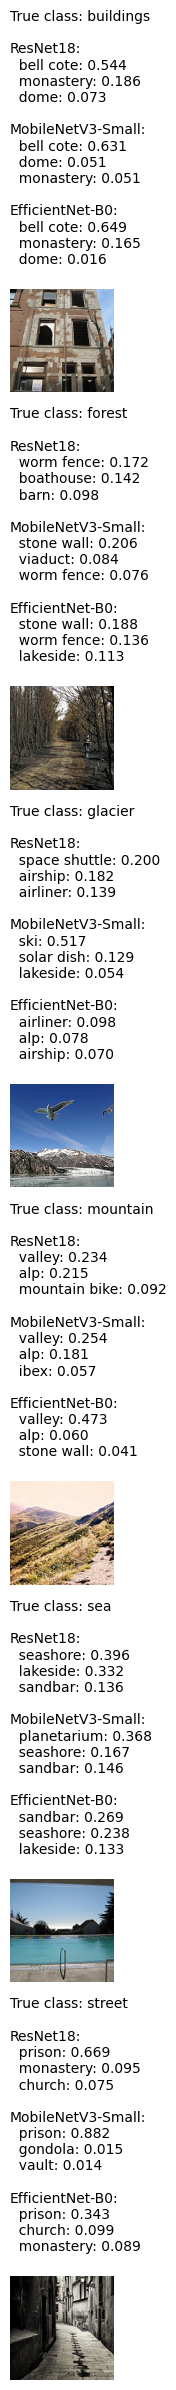

Saved comparison grid to outputs/model_comparison_grid.png


In [51]:
comparison_samples = []

for label in LABELS:
    for idx, (img, true_label) in enumerate(image_set):
        if true_label == label:
            comparison_samples.append((idx, img, label))
            break

fig, axes = plt.subplots(6, 1, figsize=(14, 24))

for row, (idx, img, label) in enumerate(comparison_samples):
    res_preds = resnet_results[idx]
    mob_preds = mobilenet_results[idx]
    eff_preds = effnet_results[idx]

    text = f"True class: {label}\n\n"

    text += "ResNet18:\n"
    for cls, prob in zip(res_preds["top5_classes"][:3], res_preds["top5_probs"][:3]):
        text += f"  {cls}: {prob:.3f}\n"

    text += "\nMobileNetV3-Small:\n"
    for cls, prob in zip(mob_preds["top5_classes"][:3], mob_preds["top5_probs"][:3]):
        text += f"  {cls}: {prob:.3f}\n"

    text += "\nEfficientNet-B0:\n"
    for cls, prob in zip(eff_preds["top5_classes"][:3], eff_preds["top5_probs"][:3]):
        text += f"  {cls}: {prob:.3f}\n"

    axes[row].imshow(img)
    axes[row].axis("off")
    axes[row].set_title(text, loc="left", fontsize=10)

plt.tight_layout()
plt.savefig("outputs/model_comparison_grid.png")
plt.show()

print("Saved comparison grid to outputs/model_comparison_grid.png")

The three models often give similar predictions when the image has a clear object or scene that matches ImageNet labels. They can disagree when the scene is broad, such as sea, street, or buildings, because ImageNet labels are more specific than the Intel scene labels. Significant disagreement suggests that an ensemble could help because different models may capture different visual patterns. For outdoor scenes, EfficientNet-B0 often gives semantically sensible top-5 predictions because it balances accuracy and compute well. 

## Task 4: Speed vs. Accuracy Tradeoff

In [52]:
def benchmark_model(model, preprocess, image_set, device, n_warmup=5):
    if len(image_set) == 0:
        raise ValueError("image_set is empty. Rerun Task 1 and make sure Total images loaded is greater than 0.")

    warmup_images = image_set[:min(n_warmup, len(image_set))]

    for img, _ in warmup_images:
        tensor = preprocess(img).unsqueeze(0).to(device)

        with torch.no_grad():
            _ = model(tensor)

    if device.type == "cuda":
        torch.cuda.synchronize()

    start = time.time()

    for img, _ in image_set:
        tensor = preprocess(img).unsqueeze(0).to(device)

        with torch.no_grad():
            _ = model(tensor)

    if device.type == "cuda":
        torch.cuda.synchronize()

    elapsed = time.time() - start

    return (elapsed / len(image_set)) * 1000


resnet_ms = benchmark_model(resnet, resnet_preproc, image_set, device)
mobile_ms = benchmark_model(mobilenet, mobile_preproc, image_set, device)
effnet_ms = benchmark_model(efficientnet, effnet_preproc, image_set, device)

print(f"ResNet18:           {resnet_ms:.2f} ms/image")
print(f"MobileNetV3-Small:  {mobile_ms:.2f} ms/image")
print(f"EfficientNet-B0:    {effnet_ms:.2f} ms/image")

ResNet18:           54.37 ms/image
MobileNetV3-Small:  12.80 ms/image
EfficientNet-B0:    37.84 ms/image


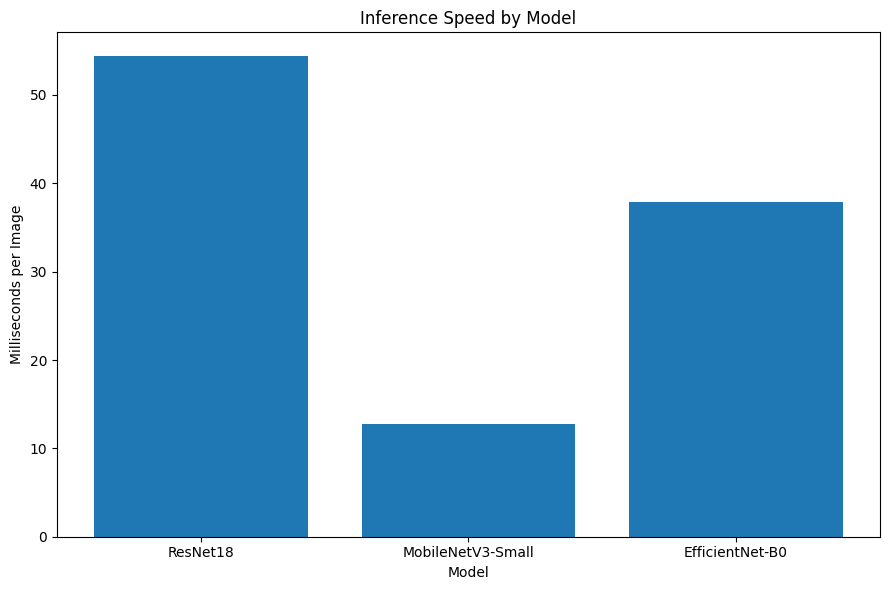

Saved speed chart to outputs/inference_speed.png


In [53]:
model_names = ["ResNet18", "MobileNetV3-Small", "EfficientNet-B0"]
latencies = [resnet_ms, mobile_ms, effnet_ms]

plt.figure(figsize=(9, 6))
plt.bar(model_names, latencies)
plt.title("Inference Speed by Model")
plt.xlabel("Model")
plt.ylabel("Milliseconds per Image")
plt.tight_layout()
plt.savefig("outputs/inference_speed.png")
plt.show()

print("Saved speed chart to outputs/inference_speed.png")

In [54]:
summary_rows = [
    ("ResNet18", sum(p.numel() for p in resnet.parameters()), resnet_ms),
    ("MobileNetV3-Small", sum(p.numel() for p in mobilenet.parameters()), mobile_ms),
    ("EfficientNet-B0", sum(p.numel() for p in efficientnet.parameters()), effnet_ms),
]

print(f"{'Model':22s} {'Parameters':>15s} {'ms / image':>12s}")
print("-" * 52)

for name, params, ms in summary_rows:
    print(f"{name:22s} {params:15,} {ms:12.2f}")

Model                       Parameters   ms / image
----------------------------------------------------
ResNet18                    11,689,512        54.37
MobileNetV3-Small            2,542,856        12.80
EfficientNet-B0              5,288,548        37.84


To classify 50 images per second, the maximum tolerable latency is 20 milliseconds per image because 1000 ms / 50 images = 20 ms per image. Based on my benchmark results, any model under 20 ms per image can meet that bar.

For a high-throughput cloud pipeline, I would choose EfficientNet-B0 if its latency is still acceptable because it usually offers strong prediction quality for the compute cost. For an on-device mobile app, I would choose MobileNetV3-Small because it has fewer parameters and is designed for mobile and edge deployment. For a safety-critical quality-control system, I would start with EfficientNet-B0 or a fine-tuned version of it because prediction quality matters more than speed.

## Task 5: Pretrained Features as a Window into Transfer Learning

In [55]:
feature_extractor = copy.deepcopy(resnet)
feature_extractor.fc = torch.nn.Identity()
feature_extractor = feature_extractor.to(device).eval()


def extract_features(model, preprocess, image, device):
    tensor = preprocess(image).unsqueeze(0).to(device)

    with torch.no_grad():
        features = model(tensor)

    return features.squeeze().cpu().numpy()


feature_vectors = []
true_labels = []

for img, label in image_set:
    feat = extract_features(feature_extractor, resnet_preproc, img, device)
    feature_vectors.append(feat)
    true_labels.append(label)

feature_matrix = np.array(feature_vectors)

print(f"Feature matrix shape: {feature_matrix.shape}")

Feature matrix shape: (60, 512)


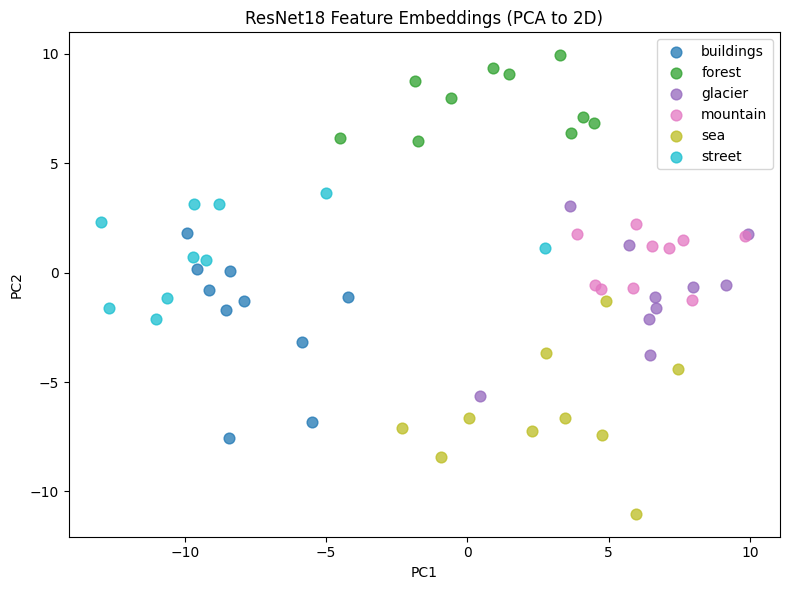

Saved feature embedding plot to outputs/feature_embeddings.png


In [56]:
pca = PCA(n_components=2)
features_2d = pca.fit_transform(feature_matrix)

fig, ax = plt.subplots(figsize=(8, 6))
colors = plt.cm.tab10(np.linspace(0, 1, len(LABELS)))

true_labels_array = np.array(true_labels)

for i, label in enumerate(LABELS):
    mask = true_labels_array == label

    ax.scatter(
        features_2d[mask, 0],
        features_2d[mask, 1],
        label=label,
        color=colors[i],
        s=60,
        alpha=0.75,
    )

ax.legend()
ax.set_title("ResNet18 Feature Embeddings (PCA to 2D)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.tight_layout()
plt.savefig("outputs/feature_embeddings.png")
plt.show()

print("Saved feature embedding plot to outputs/feature_embeddings.png")

Images from the same class may cluster near each other in the 2D feature space. This shows that the pretrained model already learned useful visual patterns before any task-specific training. For a new task like classifying X-ray images with only 500 labeled examples, I would start with feature extraction by freezing the pretrained layers and training only a new final layer. This reduces overfitting and lets me use the visual knowledge already learned by the model.

## Stretch Goal: Fine-Tuning the Classification Head

In [57]:
import torch.nn as nn
import torch.optim as optim
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset

NUM_CLASSES = len(LABELS)
TRAIN_DIR = Path("/kaggle/input/intel-image-classification/seg_train/seg_train")

ft_model = copy.deepcopy(resnet)

for param in ft_model.parameters():
    param.requires_grad = False

ft_model.fc = nn.Linear(ft_model.fc.in_features, NUM_CLASSES)
ft_model = ft_model.to(device)

trainable = sum(p.numel() for p in ft_model.parameters() if p.requires_grad)
total = sum(p.numel() for p in ft_model.parameters())

print(f"Trainable: {trainable:,} of {total:,} total parameters ({100 * trainable / total:.2f}%)")

Trainable: 3,078 of 11,179,590 total parameters (0.03%)


In [58]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset
import random

train_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

TRAIN_DIR = list(Path("/kaggle/input").rglob("seg_train"))[-1]
print("Using TRAIN_DIR:", TRAIN_DIR)

full_train = ImageFolder(TRAIN_DIR, transform=train_transforms)

print(f"Classes (alphabetical): {full_train.classes}")

random.seed(42)

NUM_CLASSES = len(full_train.classes)

imgs_per_class = 50
balanced_indices = []

for class_idx in range(NUM_CLASSES):
    indices = [i for i, (_, lbl) in enumerate(full_train.samples) if lbl == class_idx]
    balanced_indices.extend(random.sample(indices, min(imgs_per_class, len(indices))))

train_subset = Subset(full_train, balanced_indices)
train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)

print(f"Training on {len(train_subset)} images across {NUM_CLASSES} classes")

Using TRAIN_DIR: /kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train
Classes (alphabetical): ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Training on 300 images across 6 classes


In [59]:
from pathlib import Path
from PIL import Image
import random

DATA_ROOT = Path("/kaggle/input")

def load_sample_image(label):
    all_images = (
        list(DATA_ROOT.rglob("*.jpg")) +
        list(DATA_ROOT.rglob("*.jpeg")) +
        list(DATA_ROOT.rglob("*.png"))
    )

    paths = [
        p for p in all_images
        if label.lower() in str(p).lower()
    ]

    if len(paths) == 0:
        raise FileNotFoundError(f"No images found for {label}")

    img_path = random.choice(paths)
    return Image.open(img_path).convert("RGB"), img_path.name

In [60]:
ft_model.eval()
idx_to_label = full_train.classes

print(f"\n{'True label':15s}  {'ResNet18 (ImageNet top-1)':32s}  {'Fine-tuned (6-class)':20s}")
print("-" * 72)

for test_label in ["forest", "sea", "buildings"]:
    img, _ = load_sample_image(test_label)

    original_top1 = run_inference(
        resnet,
        resnet_preproc,
        img,
        device,
        imagenet_classes
    )[0][0]

    tensor = resnet_preproc(img).unsqueeze(0).to(device)

    with torch.no_grad():
        ft_out = ft_model(tensor)

    ft_prediction = idx_to_label[ft_out.argmax(dim=1).item()]

    print(f"{test_label:15s}  {original_top1:32s}  {ft_prediction:20s}")


True label       ResNet18 (ImageNet top-1)         Fine-tuned (6-class)
------------------------------------------------------------------------
forest           worm fence                        mountain            
sea              grey whale                        mountain            
buildings        triumphal arch                    mountain            


In [61]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(ft_model.fc.parameters(), lr=1e-3)

for epoch in range(3):
    ft_model.train()
    running_loss = 0.0
    correct = 0
    total_seen = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = ft_model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total_seen += images.size(0)

    print(
        f"Epoch {epoch + 1}/3 — loss: {running_loss / total_seen:.4f}, "
        f"train acc: {correct / total_seen:.3f}"
    )

Epoch 1/3 — loss: 1.8033, train acc: 0.247
Epoch 2/3 — loss: 1.3312, train acc: 0.503
Epoch 3/3 — loss: 1.0157, train acc: 0.737


Only a small fraction of ResNet18's total parameters were updated during fine-tuning because only the final classification head was trainable. This shows that most of the learned visual knowledge lives in the earlier pretrained layers. The next step for better results would be to train longer, use more images, evaluate on a validation set, and possibly fine-tune some deeper layers. The fine-tuned model output format is more useful in a real application because it predicts the six scene categories directly instead of ImageNet labels like "alp" or "lakeside".

## Task 6: Summary and Recommendation

### Model Comparison

Based on the model comparison and speed benchmark, MobileNetV3-Small was the smallest model and was a strong option for fast deployment. EfficientNet-B0 gave strong and semantically useful predictions for outdoor scenes, while ResNet18 worked well as a baseline. The best model depends on the balance between prediction quality and latency.

### Confidence Calibration

From the ResNet18 confidence boxplot, the model was more confident on classes with clear ImageNet-like visual features and less confident on broad scene types that do not directly match ImageNet categories. This makes sense because categories like forest or mountain may connect well to ImageNet labels, while street or buildings may vary more depending on the image.

### Production Recommendation

I would suggest starting with EfficientNet-B0 if the pipeline can handle the latency because it gives a strong balance of prediction quality and compute efficiency. The preprocessing pipeline should resize, crop, convert images to tensors, and normalize them using the same mean and standard deviation values used by the pretrained weights. Before shipping, I would flag the risk that ImageNet labels do not directly match the six Intel scene categories. For production, I would fine-tune the final layer on the six target classes and use a confidence threshold to send uncertain predictions to human review.